## Event analysis plots

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.analyze import analyze_file, run_analysis
from src.detection_config import DetectionConfig, ScenarioConfig
from src.ground_truth import build_expected_blinks, build_expected_saccades
from src.plots import (
    plot_blink_signal,
    plot_blink_threshold_metrics,
    plot_detected_events,
    plot_latency_distributions,
    plot_saccade_directions,
    plot_smoothing_window_effect,
    plot_speed_histogram,
    plot_threshold_sweep,
)
from src.reports import build_saccade_evaluation, summarize_evaluation_by_participant

In [2]:
SACCADE_FILE = Path("data/participant_4/SaccadeData_20260729_110441_20s.csv")
BLINK_FILE = Path("data/participant_4/BlinkData_20260729_110615_20s.csv")
FIXATION_FILE = Path("data/participant_4/FixationData_20260729_110316_20s.csv")

detection_cfg = DetectionConfig()
thesis_scenario_cfg = ScenarioConfig()

thesis_result = run_analysis(detection_cfg, thesis_scenario_cfg)
all_samples = pd.concat(thesis_result.samples.values(), ignore_index=True)
saccade_samples, saccade_events = analyze_file(SACCADE_FILE, detection_cfg)
blink_samples, _ = analyze_file(BLINK_FILE, detection_cfg)
fixation_samples, fixation_events = analyze_file(FIXATION_FILE, detection_cfg)
expected_saccades = build_expected_saccades(saccade_samples)
expected_blinks = build_expected_blinks(blink_samples, thesis_scenario_cfg)

### P1 - Angular velocity histogram (Figure 3.4)

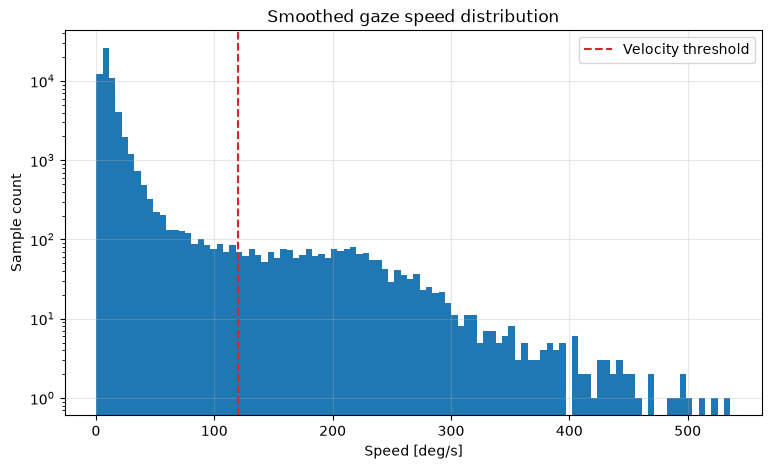

In [3]:
plot_speed_histogram(all_samples, detection_cfg);

### P2 - Detected events and target jumps

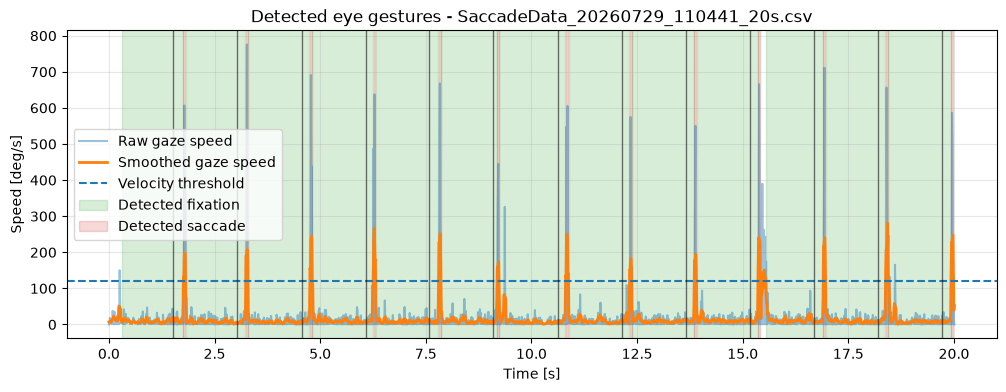

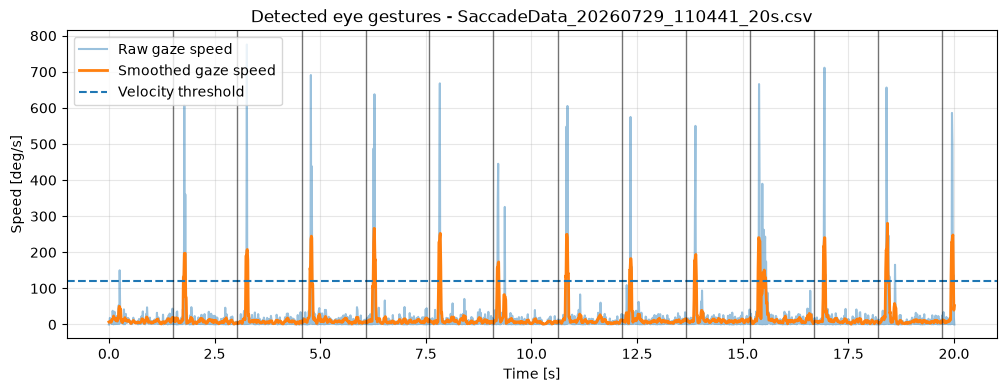

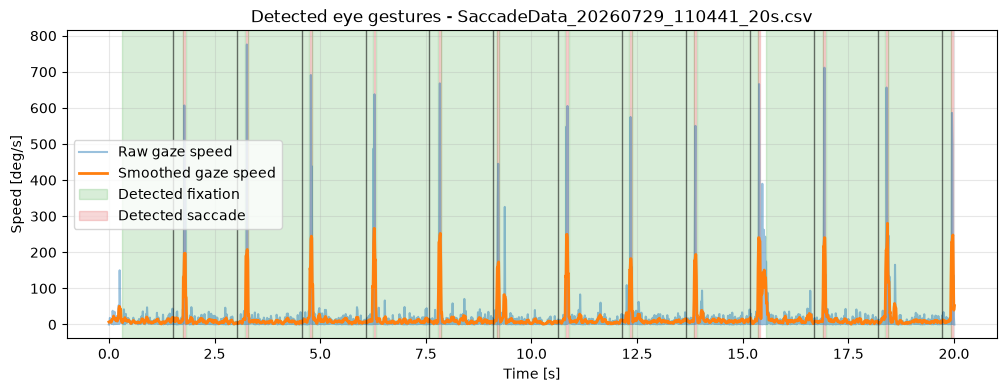

In [4]:
# detected-event coloring enabled
plot_detected_events(
    saccade_samples,
    saccade_events,
    detection_cfg,
    expected_saccades["expected_time_s"],
    show_detected_events=True,
)

# detected-event coloring disabled
plot_detected_events(
    saccade_samples,
    saccade_events,
    detection_cfg,
    expected_saccades["expected_time_s"],
    show_detected_events=False,
)

# plot without showing threshold
plot_detected_events(
    saccade_samples,
    saccade_events,
    detection_cfg,
    expected_saccades["expected_time_s"],
    show_detected_events=True,
    show_velocity_threshold=False,
);

### P3 - Blink signal with metronome markers

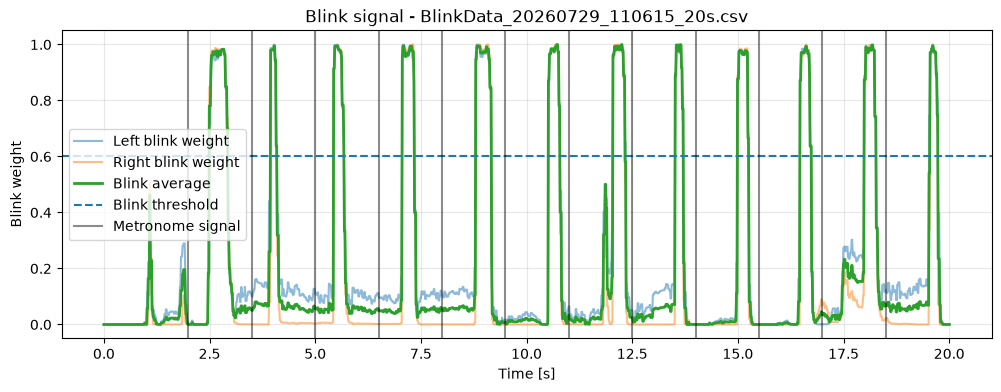

In [5]:
plot_blink_signal(blink_samples, detection_cfg, expected_blinks["expected_time_s"]);

### P4 - Sample fixation recording timeline

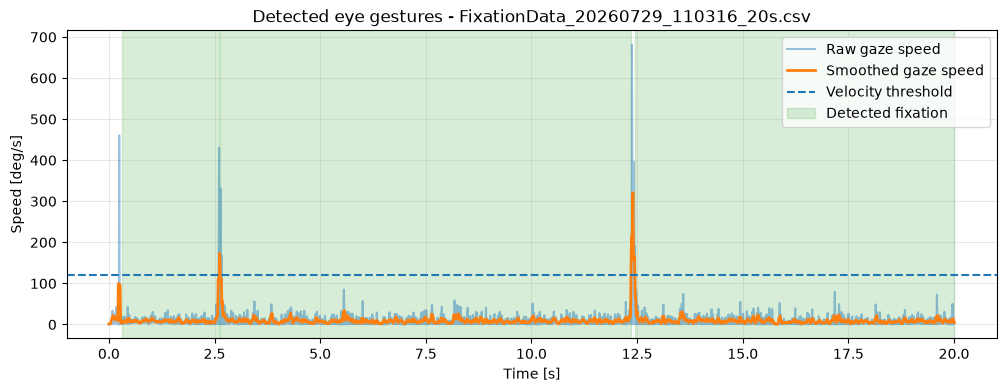

In [6]:
plot_detected_events(fixation_samples, fixation_events, detection_cfg);

### P5a - Saccade direction scatter - single recording

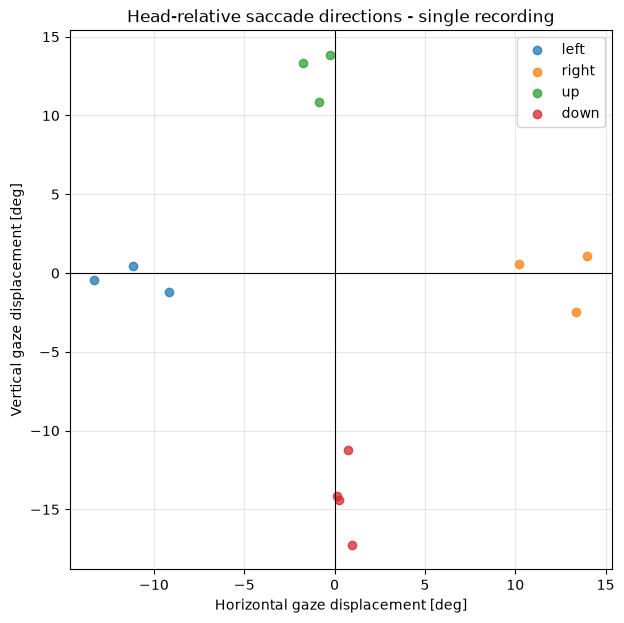

In [7]:
plot_saccade_directions(
    saccade_events,
    "Head-relative saccade directions - single recording",
);

### P5b - Saccade direction scatter - full dataset (Figure 6.2)

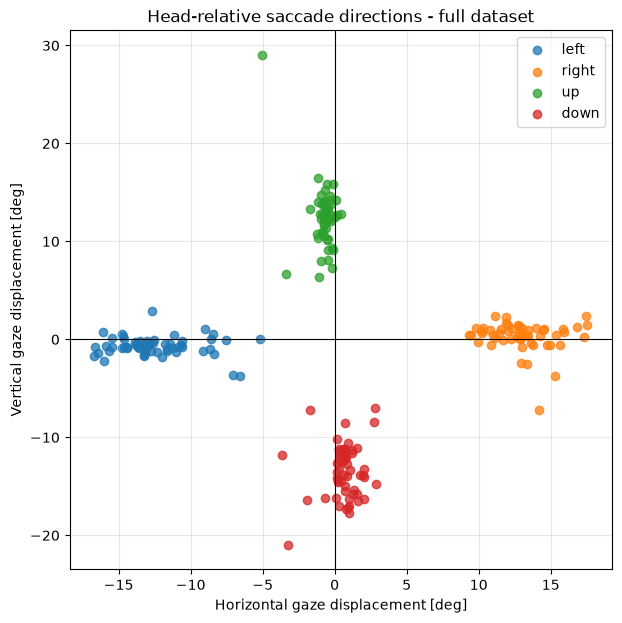

In [8]:
plot_saccade_directions(
    thesis_result.events[thesis_result.events["gesture"] == "saccade"],
    "Head-relative saccade directions - full dataset",
);

### P6 - Velocity threshold sweep (Figure 6.10)

participant,participant_1,participant_2,participant_3,participant_4,participant_5
velocity_threshold_deg_s,,,,,
40,0.800,0.778,0.645,0.893,0.943
60,0.727,0.796,0.650,0.895,0.943
80,0.800,0.796,0.678,0.895,0.943
100,1.000,0.811,0.690,0.927,0.935
120,0.889,0.819,0.717,0.933,0.943
140,1.000,0.808,0.763,0.923,0.933
160,1.000,0.843,0.733,0.898,0.913
180,1.000,0.833,0.641,0.800,0.854


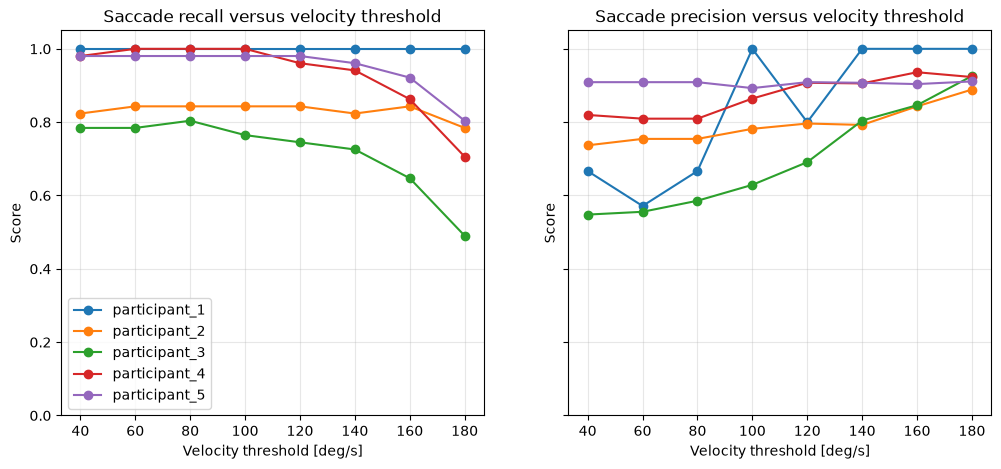

In [9]:
sweep_rows = []
for threshold in range(40, 181, 20):
    sweep_result = run_analysis(
        DetectionConfig(velocity_threshold_deg_s=float(threshold)),
        thesis_scenario_cfg,
    )
    by_participant = summarize_evaluation_by_participant(
        build_saccade_evaluation(sweep_result.saccade_matches, sweep_result.events)
    )
    by_participant["velocity_threshold_deg_s"] = threshold
    sweep_rows.append(by_participant)

sweep = pd.concat(sweep_rows, ignore_index=True)

display(
    sweep.pivot(
        index="velocity_threshold_deg_s", columns="participant", values="f1"
    ).round(3)
)
plot_threshold_sweep(sweep);

## Blink signal comparison between participant 4 and 5 (Figures 6.6 and 6.7)

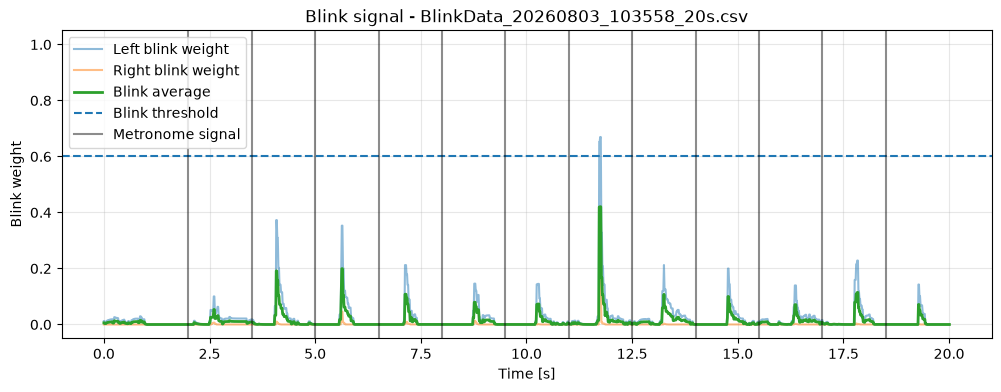

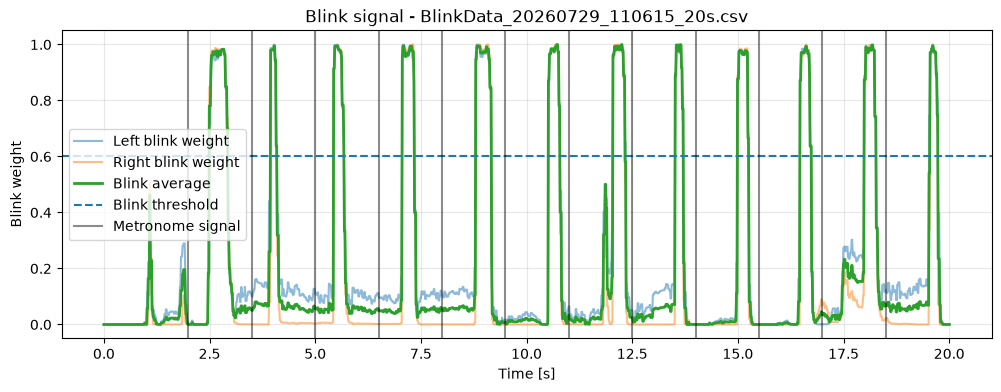

In [10]:
BLINK_FILE_P4 = Path("data/participant_4/BlinkData_20260729_110615_20s.csv")
BLINK_FILE_P5 = Path("data/participant_5/BlinkData_20260803_103558_20s.csv")

for blink_path in (BLINK_FILE_P5, BLINK_FILE_P4):
    samples, _ = analyze_file(blink_path, detection_cfg)
    expected = build_expected_blinks(samples, thesis_scenario_cfg)
    plot_blink_signal(samples, detection_cfg, expected["expected_time_s"])
    plt.show()

## Saccades detected during blink events in combined scenario (Figure 6.8 and Figure 6.9)

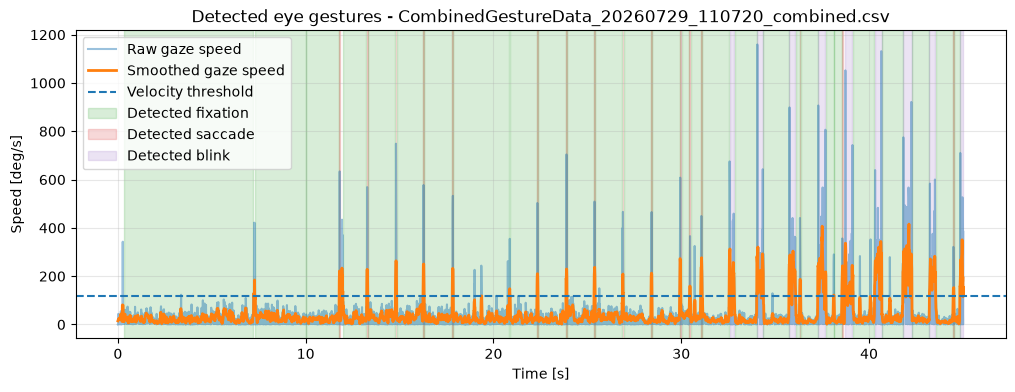

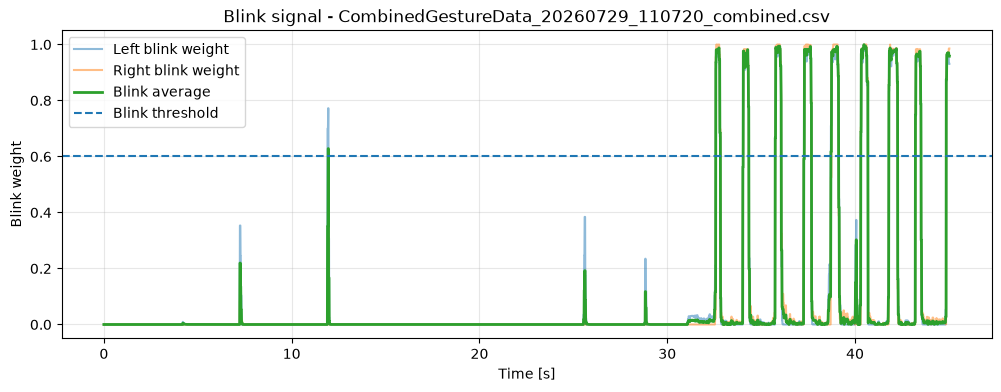

In [11]:
COMBINED_FILE = Path(
    "data/participant_4/CombinedGestureData_20260729_110720_combined.csv"
)

combined_samples, combined_events = analyze_file(COMBINED_FILE, detection_cfg)
plot_detected_events(combined_samples, combined_events, detection_cfg)
plt.show()

plot_blink_signal(combined_samples, detection_cfg)
plt.show()

## Smoothing window effect on saccade detection (Figure 3.6)

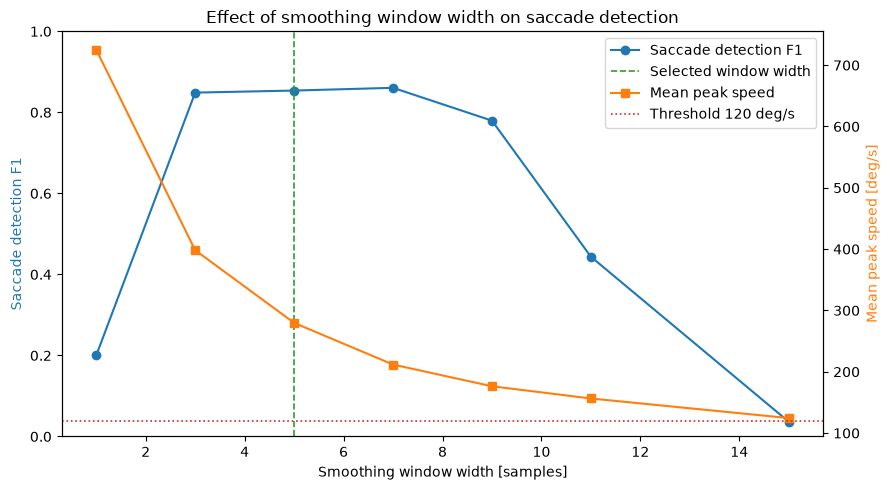

In [12]:
plot_smoothing_window_effect(
    detection_cfg,
    thesis_scenario_cfg,
    windows=[1, 3, 5, 7, 9, 11, 15],
);

## Detection latency and matching windows (Figure 6.1 and Figure 6.5)

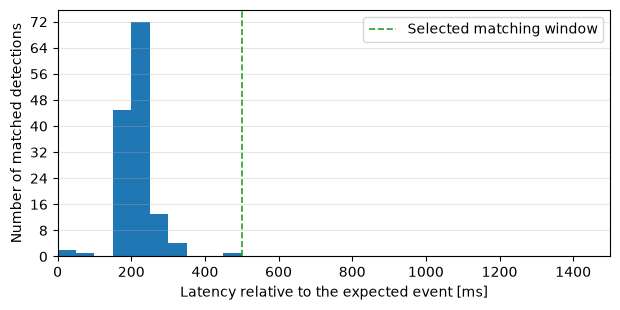

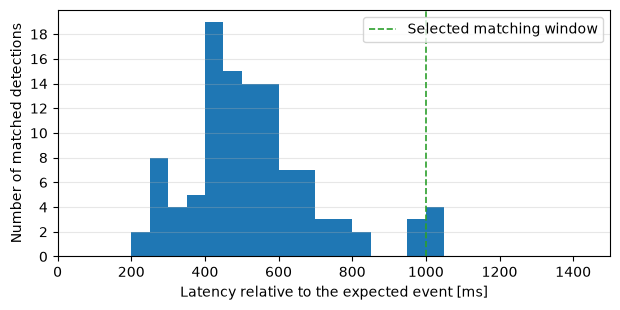

In [ ]:
# first histogram shows saccade latencies
# second histogram shows blink latencies
# latency relative to target jump (saccade) or sound signal (blink)

plot_latency_distributions(
    detection_cfg,
    thesis_scenario_cfg,
    max_window_s=1.5,
    bin_width_ms=50,
);

## Blink threshold effect on detection metrics (Figure 3.5)

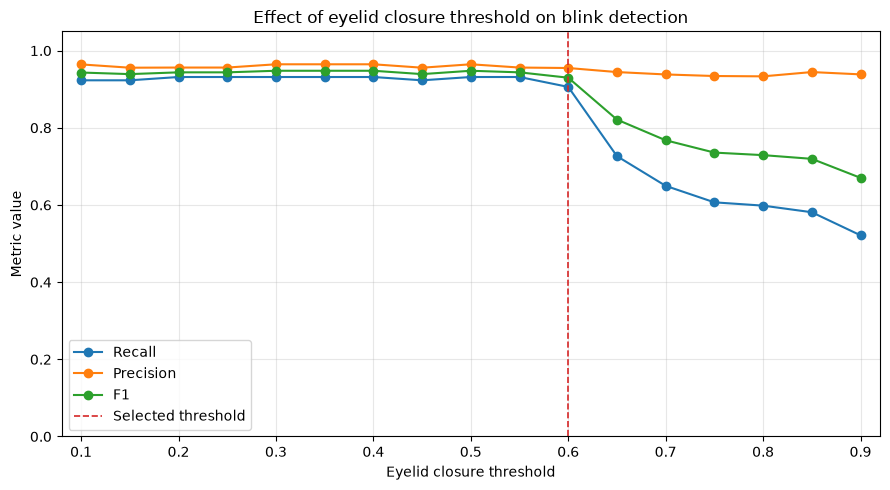

In [14]:
plot_blink_threshold_metrics(
    detection_cfg,
    thesis_scenario_cfg,
    participants=["participant_1", "participant_2", "participant_3", "participant_4"],
);